<a href="https://colab.research.google.com/github/rogerioluizsi/GrowthMindsetTeacherExpectationPaper/blob/main/Equidade_info_pnas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title Ler dados
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

drive.mount('/content/drive')

variaveis_alunos = ["ID_ONDA","ID_ESCOLA", "SIGLA_UF", "CO_MUNICIPIO", "TIPO_DEPENDENCIA", "TIPO_CATEGORIA", "TIPO_LOCALIZACAO",
            "IN_CAPITAL", "PESO", "API01", "API03", "API05", "API06", "API07", "API07a", "API07b", "API09",
            "API18", "API21", "ACS01", "ACS02", "ACS03", "ACS04","ACS05" ,"APE01", "APE02", "APE03", "APE07", "APE08",
            "APE09", "APJ02", "APJ01", "APJ03", "APJ05", "APJ06", "APJ07", "APJ09", "APJ10", "APJ11", "APJ12",
            "APJ13", "APJ14", "APJ15", "APJ16", "APJ17", "APJ18", "AHL01", "AAC01", "AAC03", "AAC04", "AAC05",
            "AAC06", "AAC07", "AAC08", "AAC20", "AAC21", "AAC22", "AAC23", "AAC24", "AAC25", "AAC26", "APF01",
            "APF02", "APF03", "APF04", "APF05", "APF06", "AAA01", "AAA02", "AHL03", "AHL03a"]

variaveis_docentes = ["ID_ONDA","ID_ESCOLA", "SIGLA_UF", "CO_MUNICIPIO", "TIPO_DEPENDENCIA", "TIPO_CATEGORIA", "TIPO_LOCALIZACAO",
    "IN_CAPITAL", "PESO", "PAA01", "PAA02", "PAA03", "PAA04", "PAA05", "PAA06", "PAA07", "PAA08",
    "PAA09", "PAA10", "PAA11", "PAA12", "PAA13", "PAA14", "PCS01"]

variaveis_gestores = ["ID_ONDA","ID_ESCOLA", "SIGLA_UF", "CO_MUNICIPIO", "TIPO_DEPENDENCIA", "TIPO_CATEGORIA",
    "TIPO_LOCALIZACAO", "IN_CAPITAL", "PESO", "GPE04"]

gestores = pd.read_csv("/content/drive/MyDrive/equidade_project/Dados/gestores.csv", usecols = variaveis_gestores)
alunos = pd.read_csv("/content/drive/MyDrive/equidade_project/Dados/alunos.csv", usecols = variaveis_alunos)
docentes = pd.read_csv("/content/drive/MyDrive/equidade_project/Dados/docentes.csv",usecols = variaveis_docentes)

Mounted at /content/drive


 - 57 escolas tiveram alunos avaliados em leitura [ACHIEVMENT MEASUREMENT]
 - 47 escolas tiveram alunos perguntados sobre o protagonismo juvenil [MINDSET MEASUREMENT]
 - 0 possuem alunos que responderam sobre as duas questões
 - 36 escolas tiveram mensuradas as duas medidas
 - Das 36 escolas, 17.77% (422 alunos)  tem informações socioeconomicas [SES MEASUREMENT]
------------------------------------------------
Como os alunos estão distribuídos por escola:


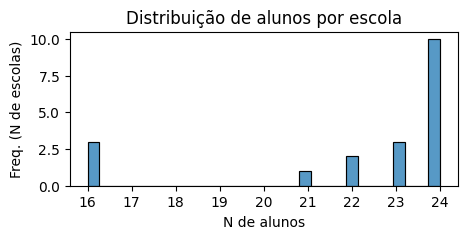

In [3]:
# @title Análise do alunos em suas escolas

# Get schools with reading and mindset assessments
escolas_avaliadas_leitura = alunos.loc[~alunos["AHL03"].isna(), "ID_ESCOLA"]
escolas_avaliadas_mindset = alunos.loc[~alunos["APJ12"].isna(), "ID_ESCOLA"]

# Print basic statistics
print(f" - {escolas_avaliadas_leitura.nunique()} escolas tiveram alunos avaliados em leitura [ACHIEVMENT MEASUREMENT]")
print(f" - {escolas_avaliadas_mindset.nunique()} escolas tiveram alunos perguntados sobre o protagonismo juvenil [MINDSET MEASUREMENT]")

# Get schools with both measures using sets (more efficient than Series.isin())
conjunto_leitura = set(escolas_avaliadas_leitura)
conjunto_mindset = set(escolas_avaliadas_mindset)
escolas_duas_medidas = conjunto_leitura.intersection(conjunto_mindset)
n_escolas_duas_medidas = len(escolas_duas_medidas)

print(f" - {alunos.dropna(subset=['AHL03', 'APJ12']).shape[0]} possuem alunos que responderam sobre as duas questões")

print(f" - {n_escolas_duas_medidas} escolas tiveram mensuradas as duas medidas")

# Create filtered dataset
dataset = alunos.loc[alunos["ID_ESCOLA"].isin(escolas_duas_medidas)].copy()
df = dataset.dropna(subset=['ACS01', 'ACS02', 'ACS03', 'ACS04'])[['ID_ESCOLA','PESO','ACS01', 'ACS02', 'ACS03', 'ACS04','AHL03','APJ12','APJ13']]

# Calculate and print ratio with formatted percentage
ratio = df.shape[0] / dataset.shape[0]
print(f" - Das {n_escolas_duas_medidas} escolas, {ratio:.2%} ({df.shape[0]} alunos)  tem informações socioeconomicas [SES MEASUREMENT]")
print("------------------------------------------------")
print("Como os alunos estão distribuídos por escola:")
# Count observations and create bar plot
# Using seaborn for a cleaner look
import seaborn as sns

plt.figure(figsize=(5, 2))
sns.histplot(df.groupby("ID_ESCOLA").size(), bins=30)
plt.title('Distribuição de alunos por escola')
plt.xlabel('N de alunos')
plt.ylabel('Freq. (N de escolas)')
plt.show()


# Funcoes
def set_growth_mindset(row):
  if row['APJ12'] == 2 and row['APJ13'] == 2:
    return 0
  elif row['APJ12'] == 0 and row['APJ13'] == 0:
    return 1
  else:
    return np.nan

def media_ponderada(group, coluna_valor, coluna_peso):
    valores = group[coluna_valor]
    pesos = group[coluna_peso]
    if pesos.sum() > 0:
        return (valores * pesos).sum() / pesos.sum()
    else:
        return None




 Set measurements using just students from school with all dimensions:

- Growth mindset variable at the school level for each student.

- Achievment variable at the school level for each student

- PCA_SES variable at Student Level

 There are 308 students who answered about mindset
 Only 126 answered 0 or 2 and will be included
 That means 3.71 students by school in average
 There are 34 schools
--------------------------------


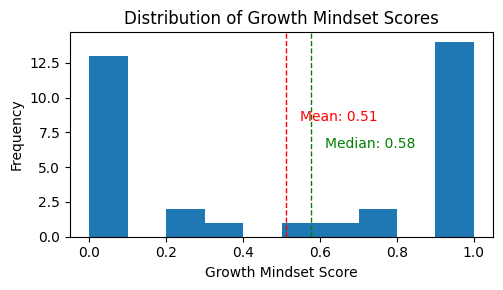

In [4]:
# @title Growth Mindset
#Take only students with mindset data from schools with two measures
df_mindset = alunos[alunos["ID_ESCOLA"].isin(escolas_duas_medidas)]
df_mindset = df_mindset.dropna(subset=["APJ12", "APJ13"])

print(f" There are {df_mindset.shape[0]} students who answered about mindset")
df_mindset['growth_mindset'] = df_mindset.apply(set_growth_mindset, axis=1)
df_mindset = df_mindset.dropna(subset=["growth_mindset"])
print(f" Only {df_mindset.shape[0]} answered 0 or 2 and will be included")

average_students_school = df_mindset.groupby("ID_ESCOLA").size().mean()
print(f" That means {round(average_students_school, 2)} students by school in average")

print(f" There are {df_mindset.ID_ESCOLA.nunique()} schools")


df_mindset = df_mindset[['ID_ESCOLA','PESO','growth_mindset']]


df_mindset = df_mindset.groupby('ID_ESCOLA').apply(
    media_ponderada,
    'growth_mindset',
    'PESO'
).reset_index()

df_mindset.columns = ['ID_ESCOLA', 'W_AVG_growth_mindset']



## Plot
import matplotlib.pyplot as plt
import numpy as np

# Create the histogram
plt.figure(figsize=(5, 3))
df_mindset["W_AVG_growth_mindset"].plot(kind="hist", bins=10)

# Calculate mean and median
mean_val = df_mindset["W_AVG_growth_mindset"].mean()
median_val = df_mindset["W_AVG_growth_mindset"].median()

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1)
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1)

print("--------------------------------")
# Add annotations
plt.annotate(f'Mean: {mean_val:.2f}',
            xy=(mean_val, plt.ylim()[1]*0.5),
            xytext=(10, 10),
            textcoords='offset points',
            color='red')

plt.annotate(f'Median: {median_val:.2f}',
            xy=(median_val, plt.ylim()[1]*0.5),
            xytext=(10, -10),
            textcoords='offset points',
            color='green')

plt.title('Distribution of Growth Mindset Scores')
plt.xlabel('Growth Mindset Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()





 There are 731 students who has achievement data
 That means 20.31 students by school in average
 There are 36 schools
--------------------------------


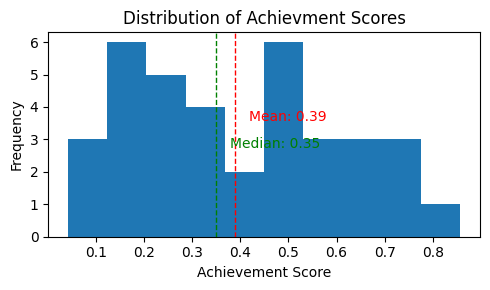

In [5]:
# @title Achievement at the school level
#Take only students with achievment data from schools with the two measures
df_achievement = alunos[alunos["ID_ESCOLA"].isin(escolas_duas_medidas)]

#take out possible students wo ses data
df_achievement = df_achievement.dropna(subset=["AHL03"])

print(f" There are {df_achievement.shape[0]} students who has achievement data")

average_students_school = df_achievement.groupby("ID_ESCOLA").size().mean()
print(f" That means {round(average_students_school, 2)} students by school in average")

print(f" There are {df_achievement.ID_ESCOLA.nunique()} schools")

# 1 if it aswered correcly, 0 otherwise.

df_achievement["RESPOSTA_TIRINHA"] = df_achievement["AHL03"].apply(lambda x: 0 if x != 1 else 1)
df_achievement = df_achievement.groupby('ID_ESCOLA').apply(
    media_ponderada,
    'RESPOSTA_TIRINHA',
    'PESO'
).reset_index()

df_achievement.columns = ['ID_ESCOLA', 'W_AVG_achievement']


## Plot
import matplotlib.pyplot as plt
import numpy as np

# Create the histogram
plt.figure(figsize=(5, 3))
df_achievement["W_AVG_achievement"].plot(kind="hist", bins=10)

# Calculate mean and median
mean_val = df_achievement["W_AVG_achievement"].mean()
median_val = df_achievement["W_AVG_achievement"].median()

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1)
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1)

print("--------------------------------")
# Add annotations
plt.annotate(f'Mean: {mean_val:.2f}',
            xy=(mean_val, plt.ylim()[1]*0.5),
            xytext=(10, 10),
            textcoords='offset points',
            color='red')

plt.annotate(f'Median: {median_val:.2f}',
            xy=(median_val, plt.ylim()[1]*0.5),
            xytext=(10, -10),
            textcoords='offset points',
            color='green')

plt.title('Distribution of Achievment Scores')
plt.xlabel('Achievement Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()





 There are 99 teacher who answered expectation information
 There are 32 schools
 That means 3.09 teacher by school in average
--------------------------------


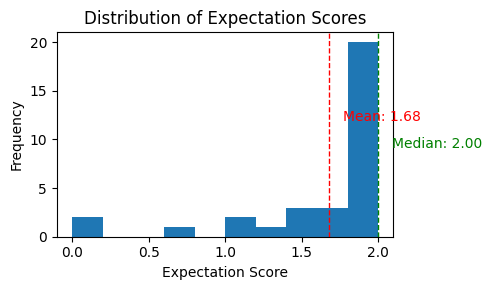

In [6]:
# @title Teacher expectation at the school level
#Take only teacher  from schools with the two measures
df_teacher = docentes[docentes["ID_ESCOLA"].isin(escolas_duas_medidas)]


#take out teacher wo expectations data data
df_teacher = df_teacher.dropna(subset=["PAA03"])

print(f" There are {df_teacher.shape[0]} teacher who answered expectation information")
print(f" There are {df_teacher.ID_ESCOLA.nunique()} schools")


average_teacher_school = df_teacher.groupby("ID_ESCOLA").size().mean()
print(f" That means {round(average_teacher_school, 2)} teacher by school in average")


# 1 if it aswered correcly, 0 otherwise.

df_teacher = df_teacher.groupby('ID_ESCOLA').apply(
    media_ponderada,
    'PAA03',
    'PESO'
).reset_index()

df_teacher.columns = ['ID_ESCOLA', 'W_AVG_expectation']


## Plot
import matplotlib.pyplot as plt
import numpy as np

# Create the histogram
plt.figure(figsize=(5, 3))
df_teacher["W_AVG_expectation"].plot(kind="hist", bins=10)

# Calculate mean and median
mean_val = df_teacher["W_AVG_expectation"].mean()
median_val = df_teacher["W_AVG_expectation"].median()

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1)
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1)

print("--------------------------------")
# Add annotations
plt.annotate(f'Mean: {mean_val:.2f}',
            xy=(mean_val, plt.ylim()[1]*0.5),
            xytext=(10, 10),
            textcoords='offset points',
            color='red')

plt.annotate(f'Median: {median_val:.2f}',
            xy=(median_val, plt.ylim()[1]*0.5),
            xytext=(10, -10),
            textcoords='offset points',
            color='green')

plt.title('Distribution of Expectation Scores')
plt.xlabel('Expectation Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()





There are 422 students who has SES data
There are 19 schools
This is 22.21, students by school in average


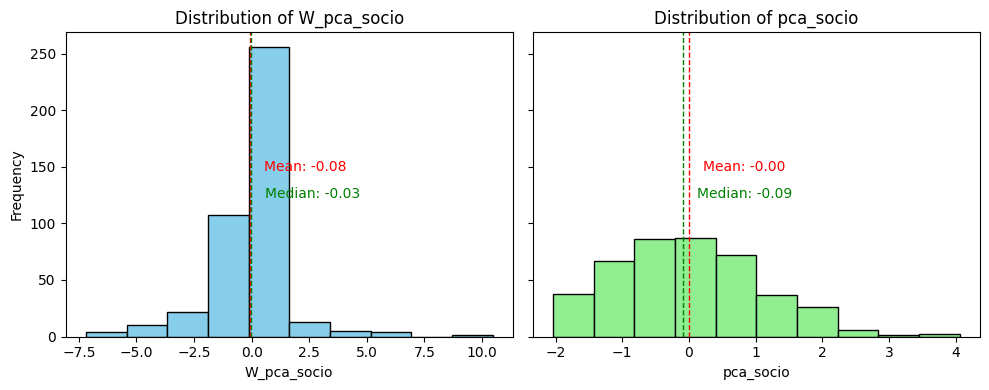

In [7]:
# @title SES at the student level - Weighted and Non-weighted version
#Take only students with achievment data from schools with the two measures


df_ses = alunos[alunos["ID_ESCOLA"].isin(escolas_duas_medidas)]
df_ses = df_ses.dropna(subset=['ACS01', 'ACS02', 'ACS03', 'ACS04'])[['ID_ESCOLA','PESO','ACS01', 'ACS02', 'ACS03', 'ACS04']]
print(f"There are {df_ses.shape[0]} students who has SES data")
print(f"There are {df_ses.ID_ESCOLA.nunique()} schools")

df_ses["quarto_pessoas"] = df_ses["ACS02"] /df_ses["ACS03"]

colunas_valor_alunos = ["quarto_pessoas", "ACS01", "ACS04"]
data_scaled = scaler.fit_transform(df_ses[colunas_valor_alunos])
pca = PCA(n_components=2)

# Fit and transform the data
pca_result = pca.fit_transform(data_scaled)

# Variance explained by the components
#print("Variance explained by each component:")
#print(pca.explained_variance_ratio_)
df_ses["pca_socio"] = pca_result[:,0]

df_ses["W_pca_socio"] = df_ses["pca_socio"]*df_ses["PESO"]


average_students_school = df_ses.groupby("ID_ESCOLA").size().mean()
print(f"This is {round(average_students_school, 2)}, students by school in average")


df_ses = df_ses[['ID_ESCOLA','W_pca_socio','pca_socio']]


## Plot
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Histogram for W_pca_socio
df_ses["W_pca_socio"].plot(kind="hist", bins=10, ax=axes[0], color="skyblue", edgecolor="black")
mean_val_w = df_ses["W_pca_socio"].mean()
median_val_w = df_ses["W_pca_socio"].median()
axes[0].axvline(mean_val_w, color='red', linestyle='dashed', linewidth=1)
axes[0].axvline(median_val_w, color='green', linestyle='dashed', linewidth=1)
axes[0].annotate(f'Mean: {mean_val_w:.2f}',
                 xy=(mean_val_w, axes[0].get_ylim()[1]*0.5),
                 xytext=(10, 10),
                 textcoords='offset points',
                 color='red')
axes[0].annotate(f'Median: {median_val_w:.2f}',
                 xy=(median_val_w, axes[0].get_ylim()[1]*0.5),
                 xytext=(10, -10),
                 textcoords='offset points',
                 color='green')
axes[0].set_title('Distribution of W_pca_socio')
axes[0].set_xlabel('W_pca_socio')
axes[0].set_ylabel('Frequency')

# Histogram for ses_pca
df_ses["pca_socio"].plot(kind="hist", bins=10, ax=axes[1], color="lightgreen", edgecolor="black")
mean_val_ses = df_ses["pca_socio"].mean()
median_val_ses = df_ses["pca_socio"].median()
axes[1].axvline(mean_val_ses, color='red', linestyle='dashed', linewidth=1)
axes[1].axvline(median_val_ses, color='green', linestyle='dashed', linewidth=1)
axes[1].annotate(f'Mean: {mean_val_ses:.2f}',
                 xy=(mean_val_ses, axes[1].get_ylim()[1]*0.5),
                 xytext=(10, 10),
                 textcoords='offset points',
                 color='red')
axes[1].annotate(f'Median: {median_val_ses:.2f}',
                 xy=(median_val_ses, axes[1].get_ylim()[1]*0.5),
                 xytext=(10, -10),
                 textcoords='offset points',
                 color='green')
axes[1].set_title('Distribution of pca_socio')
axes[1].set_xlabel('pca_socio')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()



In [8]:
# @title Merging (Achievement + Mindset school variables) -> students SES data
df = df_ses.merge(
    df_mindset, on="ID_ESCOLA", how="left").merge(
        df_achievement, on="ID_ESCOLA", how="left").merge(
            df_teacher,on="ID_ESCOLA", how="left")


print(f"At the end we have {df.shape[0]} students from {df.ID_ESCOLA.nunique()} schools with all measures")
print("These students are all students who studied in schools which have the two measures and at the same time have SES data (round 1)")
data = df.copy()


At the end we have 422 students from 19 schools with all measures
These students are all students who studied in schools which have the two measures and at the same time have SES data (round 1)


In [9]:
# @title Distribution of groups using the median as threshold
RED = '\033[91m'
BLUE = '\033[94m'
RESET = '\033[0m'
below_below = data.loc[(data.W_AVG_growth_mindset <= data.W_AVG_growth_mindset.median()) & (data.W_AVG_expectation <= data.W_AVG_expectation.median())]
below_above = data.loc[(data.W_AVG_growth_mindset <= data.W_AVG_growth_mindset.median()) & (data.W_AVG_expectation > data.W_AVG_expectation.median())]
above_below = data.loc[(data.W_AVG_growth_mindset > data.W_AVG_growth_mindset.median()) & (data.W_AVG_expectation <= data.W_AVG_expectation.median())]
above_above = data.loc[(data.W_AVG_growth_mindset > data.W_AVG_growth_mindset.median()) & (data.W_AVG_expectation > data.W_AVG_expectation.median())]

print(f"{RED}Fixed mindset{RESET}|{RED} Low expectation{RESET} schools: {below_below.ID_ESCOLA.nunique()} Students: {below_below.shape[0]}")
print(f"{RED}Fixed mindset{RESET}|{BLUE}High expectation{RESET} schools: {below_above.ID_ESCOLA.nunique()} Students: {below_above.shape[0]}")
print(f"{BLUE}Growth mindset{RESET}|{RED}Low expectation{RESET} schools: {above_below.ID_ESCOLA.nunique()} Students: {above_below.shape[0]}")
print(f"{BLUE}Growth mindset{RESET}| {BLUE}High expectation{RESET} schools: {above_above.ID_ESCOLA.nunique()} Students: {above_above.shape[0]}")


Fixed mindset| Low expectation schools: 8 Students: 185
Fixed mindset|High expectation schools: 0 Students: 0
Growth mindset|Low expectation schools: 9 Students: 198
Growth mindset| High expectation schools: 0 Students: 0


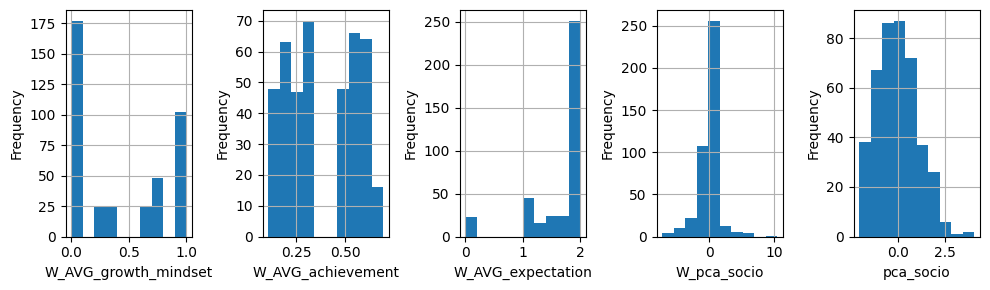

In [10]:
# @title Lets see again the variables distributions of the final dataset
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the necessary columns
# Create subplots for each numerical variable
num_vars = ['W_AVG_growth_mindset', 'W_AVG_achievement', 'W_AVG_expectation', 'W_pca_socio',"pca_socio"]
fig, axes = plt.subplots(nrows=1, ncols=len(num_vars), figsize=(10 , 3))

for i, var in enumerate(num_vars):
    df[var].hist(ax=axes[i], bins=10)  # Adjust the number of bins as needed
    #axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

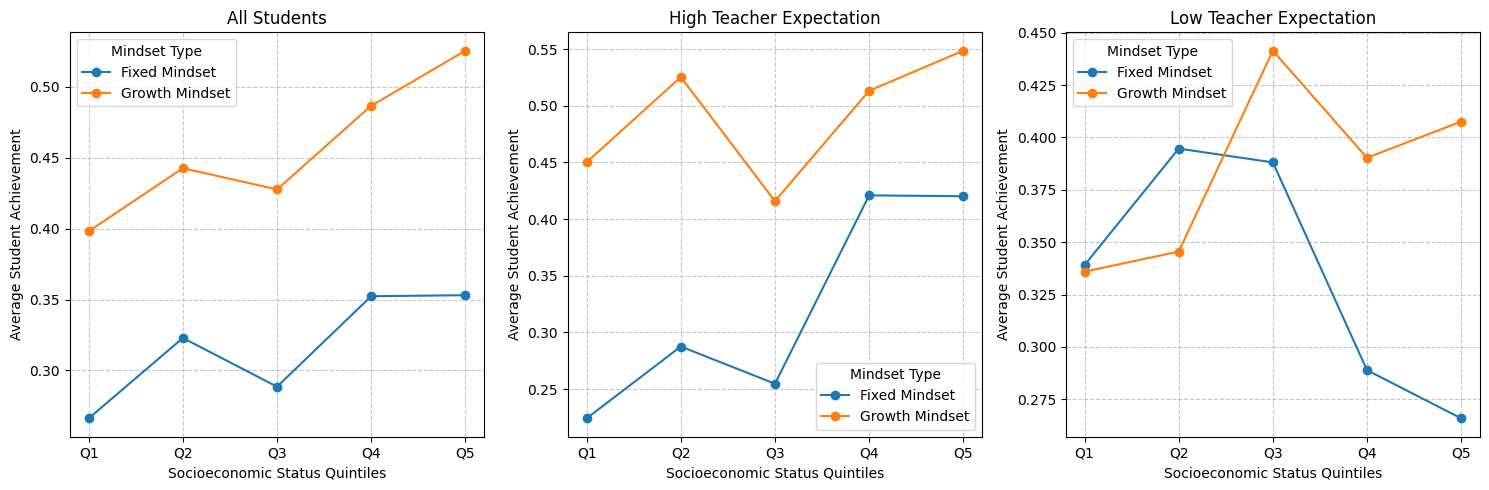

In [11]:
# @title Grafico Socio X Achievement
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def create_quintile_plots(df):
    # Create growth mindset binary classification
    df['W_AVG_growth_mindset_class'] = pd.qcut(df['W_AVG_growth_mindset'], 2, labels=['Fixed', 'Growth'])

    # Create socioeconomic quintiles
    df['socio_quintile'] = pd.qcut(df['pca_socio'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

    # Filter data based on teacher expectations
    df_high_expect = df[df['W_AVG_expectation'] >= df['W_AVG_expectation'].median()]
    df_low_expect = df[df['W_AVG_expectation'] < df['W_AVG_expectation'].median()]

    # Create a single figure with three subplots side by side
    fig, (ax3, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5))

    def plot_quintile_averages(data, ax, title):
        # Calculate means for each quintile and mindset group
        quintile_means = data.groupby(['socio_quintile', 'W_AVG_growth_mindset_class'])['W_AVG_achievement'].mean().reset_index()

        # Plot lines for each mindset group
        for mindset in ['Fixed', 'Growth']:
            mindset_data = quintile_means[quintile_means['W_AVG_growth_mindset_class'] == mindset]
            ax.plot(
                mindset_data['socio_quintile'],
                mindset_data['W_AVG_achievement'],
                marker='o',
                label=f'{mindset} Mindset'
            )

        ax.set_title(title)
        ax.set_xlabel('Socioeconomic Status Quintiles')
        ax.set_ylabel('Average Student Achievement')
        ax.legend(title='Mindset Type')
        ax.grid(True, linestyle='--', alpha=0.7)

    # Create plots for different groups
    plot_quintile_averages(df_high_expect, ax1, 'High Teacher Expectation')
    plot_quintile_averages(df_low_expect, ax2, 'Low Teacher Expectation')
    plot_quintile_averages(df, ax3, 'All Students')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
create_quintile_plots(data)

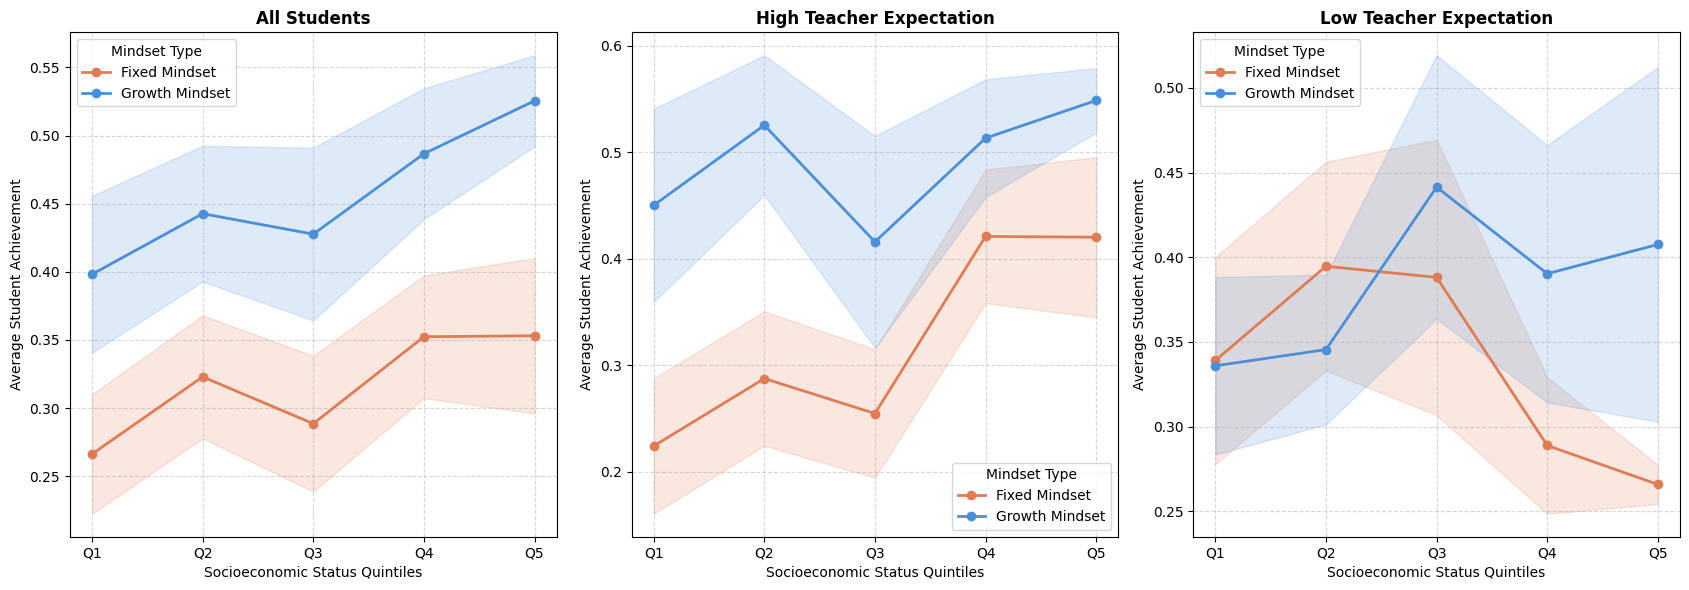

In [16]:
# @title Grafico Socio X Achievement (with CI + Regression)
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf

def create_quintile_plots(df):
    # Create growth mindset binary classification
    df['W_AVG_growth_mindset_class'] = pd.qcut(df['W_AVG_growth_mindset'], 2, labels=['Fixed', 'Growth'])

    # Create socioeconomic quintiles
    df['socio_quintile'] = pd.qcut(df['pca_socio'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    df['socio_quintile_num'] = df['socio_quintile'].cat.codes  # numeric version for regression

    # Filter data based on teacher expectations
    df_high_expect = df[df['W_AVG_expectation'] >= df['W_AVG_expectation'].median()]
    df_low_expect  = df[df['W_AVG_expectation'] <  df['W_AVG_expectation'].median()]

    # ── PLOT ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(17, 6))


    colors = {'Fixed': '#E07B54', 'Growth': '#4A90D9'}

    def plot_with_ci(data, ax, title):
        quintile_stats = (
            data.groupby(['socio_quintile', 'W_AVG_growth_mindset_class'],
                         observed=True)['W_AVG_achievement']
            .agg(['mean', 'std', 'count'])
            .reset_index()
        )
        quintile_stats['se']    = quintile_stats['std'] / np.sqrt(quintile_stats['count'])
        quintile_stats['ci95']  = 1.96 * quintile_stats['se']

        for mindset in ['Fixed', 'Growth']:
            d = quintile_stats[quintile_stats['W_AVG_growth_mindset_class'] == mindset]

            ax.plot(d['socio_quintile'].astype(str), d['mean'],
                    marker='o', label=f'{mindset} Mindset', color=colors[mindset], linewidth=2)
            ax.fill_between(
                d['socio_quintile'].astype(str),
                d['mean'] - d['ci95'],
                d['mean'] + d['ci95'],
                alpha=0.18, color=colors[mindset]
            )

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Socioeconomic Status Quintiles')
        ax.set_ylabel('Average Student Achievement')
        ax.legend(title='Mindset Type')
        ax.grid(True, linestyle='--', alpha=0.5)

    plot_with_ci(df,             axes[0], 'All Students')
    plot_with_ci(df_high_expect, axes[1], 'High Teacher Expectation')
    plot_with_ci(df_low_expect,  axes[2], 'Low Teacher Expectation')

    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
create_quintile_plots(data)